In [ ]:
import pandas as pd
import numpy as np

gen = pd.read_csv("Plant_1_Generation_Data.csv")
weather = pd.read_csv("Plant_1_Weather_Sensor_Data.csv")

gen['DATE_TIME'] = pd.to_datetime(gen['DATE_TIME'],dayfirst=True)
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'],dayfirst=True)

df = pd.merge(gen, weather, on='DATE_TIME')
df = df.sort_values('DATE_TIME')
df = df.set_index('DATE_TIME')


/tmp/ipykernel_3896/4210914007.py:8: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'],dayfirst=True)


In [ ]:
df_15 = df.resample('15min').mean(numeric_only=True)
print(df_15.head(10))

                     PLANT_ID_x  DC_POWER  AC_POWER  DAILY_YIELD  \
DATE_TIME                                                          
2020-05-15 00:00:00   4135001.0       0.0       0.0          0.0   
2020-05-15 00:15:00   4135001.0       0.0       0.0          0.0   
2020-05-15 00:30:00   4135001.0       0.0       0.0          0.0   
2020-05-15 00:45:00   4135001.0       0.0       0.0          0.0   
2020-05-15 01:00:00   4135001.0       0.0       0.0          0.0   
2020-05-15 01:15:00   4135001.0       0.0       0.0          0.0   
2020-05-15 01:30:00   4135001.0       0.0       0.0          0.0   
2020-05-15 01:45:00   4135001.0       0.0       0.0          0.0   
2020-05-15 02:00:00   4135001.0       0.0       0.0          0.0   
2020-05-15 02:15:00   4135001.0       0.0       0.0          0.0   

                      TOTAL_YIELD  PLANT_ID_y  AMBIENT_TEMPERATURE  \
DATE_TIME                                                            
2020-05-15 00:00:00  6.837223e+06   4135001

In [ ]:
df_15 = df_15.interpolate(method='linear', limit=4)
df_15=df_15.backfill().ffill()

/tmp/ipykernel_3896/1530440153.py:2: FutureWarning: DataFrame.backfill/Series.backfill is deprecated. Use DataFrame.bfill/Series.bfill instead
  df_15=df_15.backfill().ffill()


In [ ]:
df_15['clear_sky_irradiance'] = df_15['IRRADIATION'].rolling(96, min_periods=48).max()
df_15['clear_sky_index'] = df_15['IRRADIATION'] / df_15['clear_sky_irradiance']
df_15=df_15.dropna(subset=['clear_sky_irradiance'])
print(df_15['clear_sky_irradiance'].isna().sum())
print(df_15['clear_sky_index'].isna().sum())

0
0


In [ ]:
df_15['cloudiness_ratio'] = 1 - df_15['clear_sky_index']

In [ ]:
df_15['hour'] = df_15.index.hour

df_15['solar_elevation'] = np.sin((df_15['hour'] - 6) / 12 * np.pi)
df_15['solar_elevation'] = df_15['solar_elevation'].clip(lower=0)

In [ ]:
for i in range(1, 97):
    df_15[f'lag_{i}'] = df_15['AC_POWER'].shift(i)
df_15.tail(30)


/tmp/ipykernel_3896/4121150306.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15[f'lag_{i}'] = df_15['AC_POWER'].shift(i)
/tmp/ipykernel_3896/4121150306.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15[f'lag_{i}'] = df_15['AC_POWER'].shift(i)
/tmp/ipykernel_3896/4121150306.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,clear_sky_irradiance,...,lag_87,lag_88,lag_89,lag_90,lag_91,lag_92,lag_93,lag_94,lag_95,lag_96
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2020-06-17 16:30:00,4135001.0,1835.517045,179.768588,5689.794643,7.097198e+06,4135001.0,24.390767,29.473142,0.118630,1.03123,...,0.0,7.23612,33.270049,67.316234,100.920779,141.293994,170.044724,187.977597,216.470617,259.415990
2020-06-17 16:45:00,4135001.0,1132.086851,110.065666,5725.244318,7.097234e+06,4135001.0,24.291896,26.972266,0.071616,1.03123,...,0.0,0.00000,7.236120,33.270049,67.316234,100.920779,141.293994,170.044724,187.977597,216.470617
2020-06-17 17:00:00,4135001.0,1316.198864,128.153571,5752.686688,7.097261e+06,4135001.0,24.191860,25.512402,0.086473,1.03123,...,0.0,0.00000,0.000000,7.236120,33.270049,67.316234,100.920779,141.293994,170.044724,187.977597
2020-06-17 17:15:00,4135001.0,1560.422078,152.570211,5789.362825,7.097298e+06,4135001.0,24.196167,26.664971,0.104762,1.03123,...,0.0,0.00000,0.000000,0.000000,7.236120,33.270049,67.316234,100.920779,141.293994,170.044724
2020-06-17 17:30:00,4135001.0,1340.545455,130.447273,5820.318182,7.097329e+06,4135001.0,24.278404,26.862443,0.090132,1.03123,...,0.0,0.00000,0.000000,0.000000,0.000000,7.236120,33.270049,67.316234,100.920779,141.293994
2020-06-17 17:45:00,4135001.0,946.064935,91.892208,5854.655844,7.097363e+06,4135001.0,24.174170,25.950272,0.065259,1.03123,...,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,7.236120,33.270049,67.316234,100.920779
2020-06-17 18:00:00,4135001.0,605.090909,58.572078,5872.357143,7.097381e+06,4135001.0,24.130349,25.080925,0.041940,1.03123,...,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,7.236120,33.270049,67.316234
2020-06-17 18:15:00,4135001.0,338.664773,32.721591,5883.846591,7.097392e+06,4135001.0,24.038157,24.068250,0.023446,1.03123,...,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.236120,33.270049
2020-06-17 18:30:00,4135001.0,78.116883,7.537662,5889.077922,7.097397e+06,4135001.0,23.840239,22.968658,0.007007,1.03123,...,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.236120


In [ ]:
df_15= df_15.dropna()

In [ ]:

# 1 hour = 4 intervals
df_15['roll_mean_1h'] = df_15['AC_POWER'].rolling(4).mean()
df_15['roll_std_1h'] = df_15['AC_POWER'].rolling(4).std()

# 6 hours = 24 intervals
df_15['roll_mean_6h'] = df_15['AC_POWER'].rolling(24).mean()
df_15['roll_std_6h'] = df_15['AC_POWER'].rolling(24).std()

# 24 hours = 96 intervals
df_15['roll_mean_24h'] = df_15['AC_POWER'].rolling(96).mean()
df_15['roll_std_24h'] = df_15['AC_POWER'].rolling(96).std()
df_15

/tmp/ipykernel_3896/1643258770.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15['roll_mean_1h'] = df_15['AC_POWER'].rolling(4).mean()
/tmp/ipykernel_3896/1643258770.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15['roll_std_1h'] = df_15['AC_POWER'].rolling(4).std()
/tmp/ipykernel_3896/1643258770.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) inste

,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,clear_sky_irradiance,...,lag_93,lag_94,lag_95,lag_96,roll_mean_1h,roll_std_1h,roll_mean_6h,roll_std_6h,roll_mean_24h,roll_std_24h
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2020-05-16 11:45:00,4135001.0,8862.228084,866.964935,2875.715097,6.861926e+06,4135001.0,29.847392,47.043890,0.622787,0.893661,...,879.168506,930.773539,693.218561,745.526786,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-16 12:00:00,4135001.0,9018.992695,882.244724,3096.257305,6.862147e+06,4135001.0,30.089862,50.091819,0.662004,0.893661,...,930.495346,879.168506,930.773539,693.218561,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-16 12:15:00,4135001.0,7497.198052,733.950974,3306.363636,6.862357e+06,4135001.0,30.376899,48.675282,0.540425,0.893661,...,578.267127,930.495346,879.168506,930.773539,NaN,NaN,NaN,NaN,NaN,NaN
2020-05-16 12:30:00,4135001.0,10394.434253,1015.957792,3518.646104,6.862569e+06,4135001.0,30.886469,50.449570,0.767119,0.893661,...,666.635714,578.267127,930.495346,879.168506,874.779606,115.297847,NaN,NaN,NaN,NaN
2020-05-16 12:45:00,4135001.0,11154.736201,1088.891558,3783.261364,6.862834e+06,4135001.0,31.221045,54.232746,0.812241,0.893661,...,781.166315,666.635714,578.267127,930.495346,930.261262,156.365793,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-06-17 22:45:00,4135001.0,0.000000,0.000000,5889.590909,7.097398e+06,4135001.0,22.150570,21.480377,0.000000,1.031230,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,25.078941,48.733973,246.811925,342.726464
2020-06-17 23:00:00,4135001.0,0.000000,0.000000,5889.590909,7.097398e+06,4135001.0,22.129816,21.389024,0.000000,1.031230,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.739209,43.711143,246.811925,342.726464
2020-06-17 23:15:00,4135001.0,0.000000,0.000000,5889.590909,7.097398e+06,4135001.0,22.008275,20.709211,0.000000,1.031230,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.382117,33.441013,246.811925,342.726464


In [ ]:
df_15['hour'] = df_15.index.hour
df_15['day_of_week'] = df_15.index.dayofweek
df_15['month'] = df_15.index.month
df_15 = pd.get_dummies(df_15, columns=['hour', 'day_of_week', 'month'])

/tmp/ipykernel_3896/2150710082.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15['day_of_week'] = df_15.index.dayofweek
/tmp/ipykernel_3896/2150710082.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_15['month'] = df_15.index.month


In [ ]:
df_15 = df_15.dropna()
df_15.head()

,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,clear_sky_irradiance,...,hour_23,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6,month_5,month_6
DATE_TIME,,,,,,,,,,,,,,,,,,,,,
2020-05-17 11:30:00,4135001.0,12219.946429,1192.002841,3418.543831,6.868928e+06,4135001.0,32.317808,63.145582,0.977458,0.997904,...,False,False,False,False,False,False,False,True,True,False
2020-05-17 11:45:00,4135001.0,10746.393668,1048.840070,3695.455898,6.869206e+06,4135001.0,32.527864,61.801992,0.869909,0.997904,...,False,False,False,False,False,False,False,True,True,False
2020-05-17 12:00:00,4135001.0,8163.697240,798.621834,3911.634740,6.869422e+06,4135001.0,32.495968,56.101076,0.635451,0.997904,...,False,False,False,False,False,False,False,True,True,False
2020-05-17 12:15:00,4135001.0,10569.367695,1032.184010,4139.642857,6.869650e+06,4135001.0,32.985549,55.094228,0.783589,0.997904,...,False,False,False,False,False,False,False,True,True,False
2020-05-17 12:30:00,4135001.0,8347.828734,815.996997,4373.861201,6.869884e+06,4135001.0,33.108337,56.415863,0.669671,0.997904,...,False,False,False,False,False,False,False,True,True,False


#Task2


In [ ]:
horizon = 96

for i in range(1, horizon+1):
    df_15[f'target_{i}'] = df_15['AC_POWER'].shift(-i)

df_15 = df_15.dropna()

In [ ]:
features = []

# lag features
features += [col for col in df_15.columns if 'lag_' in col]

# rolling stats
features += [col for col in df_15.columns if 'roll_' in col]

# weather + engineered
features += [
    'IRRADIATION',
    'AMBIENT_TEMPERATURE',
    'clear_sky_index',
    'cloudiness_ratio',
    'solar_elevation'
]

In [ ]:
targets = [f'target_{i}' for i in range(1, 97)]

X = df_15[features]
y = df_15[targets]

In [ ]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

model = MultiOutputRegressor(RandomForestRegressor(n_estimators=30))
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=RandomForestRegressor(n_estimators=30))

In [ ]:
y_pred = model.predict(X_test)
print(y_pred.shape)   # (samples, 96)

(586, 96)


In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 76.83827959861652
RMSE: target_1      92.074977
target_2     109.088981
target_3     113.250246
target_4     117.635353
target_5     118.368798
                ...    
target_92    134.339894
target_93    129.377934
target_94    135.069258
target_95    129.831157
target_96    128.863812
Length: 96, dtype: float64


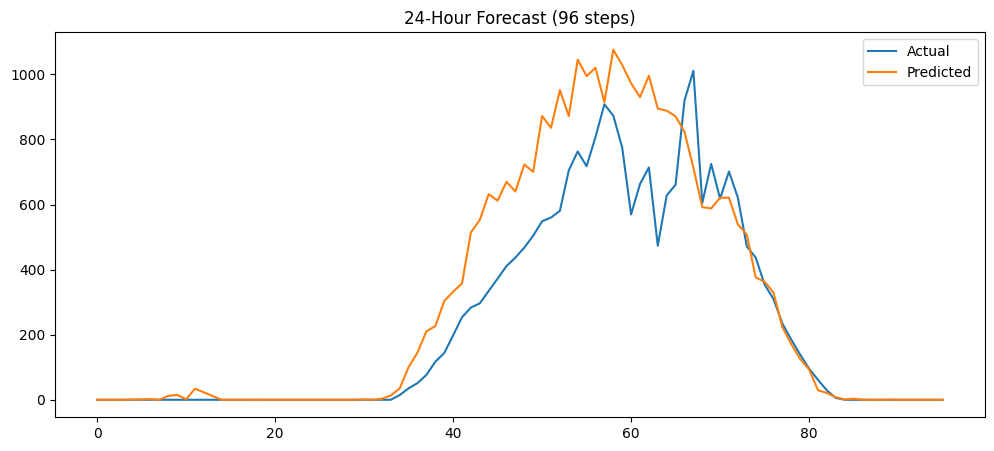

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.iloc[0].values, label="Actual")
plt.plot(y_pred[0], label="Predicted")
plt.title("24-Hour Forecast (96 steps)")
plt.legend()
plt.show()

In [ ]:
errors = y_test.values - y_pred

plt.figure(figsize=(10,5))
plt.plot(errors[0])
plt.title("Prediction Error (1 Sample)")
plt.xlabel("Time Steps (96)")
plt.ylabel("Error")
plt.show()

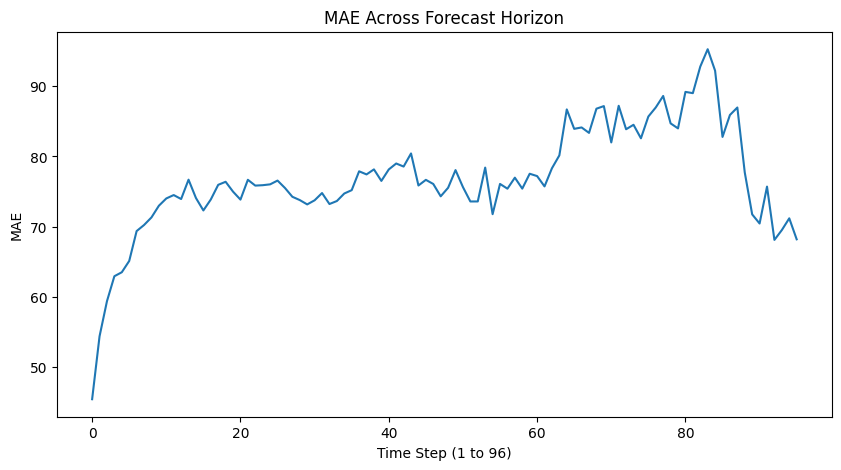

In [ ]:
import numpy as np

mae_per_step = np.mean(np.abs(y_test.values - y_pred), axis=0)

plt.figure(figsize=(10,5))
plt.plot(mae_per_step)
plt.title("MAE Across Forecast Horizon")
plt.xlabel("Time Step (1 to 96)")
plt.ylabel("MAE")
plt.show()

In [ ]:
last_input = X.iloc[-1:]

future_24h = model.predict(last_input)

print(future_24h[0])  # 96 values

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.13559091e+01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.23285823e+00
 5.85520617e+00 2.62593902e+01 7.08582996e+01 1.02014667e+02
 1.91138795e+02 2.35366839e+02 2.54344646e+02 3.42101174e+02
 3.39240887e+02 4.96424202e+02 5.55764015e+02 6.34367878e+02
 6.73392852e+02 7.08007132e+02 8.28178668e+02 7.87224886e+02
 7.32496558e+02 8.10132538e+02 9.35177968e+02 9.23657643e+02
 9.42404104e+02 8.62566558e+02 9.64198313e+02 9.48036340e+02
 6.62633643e+02 9.11060721e+02 9.09666580e+02 8.79476336e+02
 9.90249305e+02 8.99480041e+02 8.65584322e+02 8.78227880e+02
 8.94036153e+02 7.25139281e+02 6.77742584e+02 7.01497177e+02
 6.35774781e+02 6.34437127e+02 7.04154238e+02 5.87798276e+02
 4.64719830e+02 3.499491

In [ ]:
total = len(df_15)

train = int(0.8 * total)
val = int(0.1 * total)
test = total - train - val

print("Total:", total)
print("Training:", train)
print("Validation:", val)
print("Testing:", test)

Total: 2930
Training: 2344
Validation: 293
Testing: 293
